In [2]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nNotebooks found:")
for file in Path.cwd().glob("*.ipynb"):
    print(file.name)

Current working directory:
c:\Users\user\Desktop\Torch_Practices\ICBHI Respiratory Classifier

Notebooks found:
Data_Audio_Fundementals.ipynb
spectrogram_engineering.ipynb


The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


Dataset URL: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
License(s): unknown
Download complete.
Parsing: 101_1b1_Al_sc_Meditron.txt

 start    end  crackle  wheeze  label
 0.036  0.579        0       0 Normal
 0.579  2.450        0       0 Normal
 2.450  3.893        0       0 Normal
 3.893  5.793        0       0 Normal
 5.793  7.521        0       0 Normal
 7.521  9.279        0       0 Normal
 9.279 11.150        0       0 Normal
11.150 13.036        0       0 Normal
13.036 14.721        0       0 Normal
14.721 16.707        0       0 Normal
16.707 18.507        0       0 Normal
18.507 19.964        0       0 Normal

Cycles in this recording: 12
Label counts: {'Normal': 12}
Downloaded: \content\icbhi_dataset\raw\ICBHI_challenge_train_test.txt
Size: 27219 bytes

--- Split file content (first 5 rows):
                  filename  split
0  101_1b1_Al_sc_Meditron   test
1  101_1b1_Pr_sc_Meditron   test
2  102_1b1_Ar_sc_Meditron   test
3  103_2b2_Ar_mc_LittC2SE  

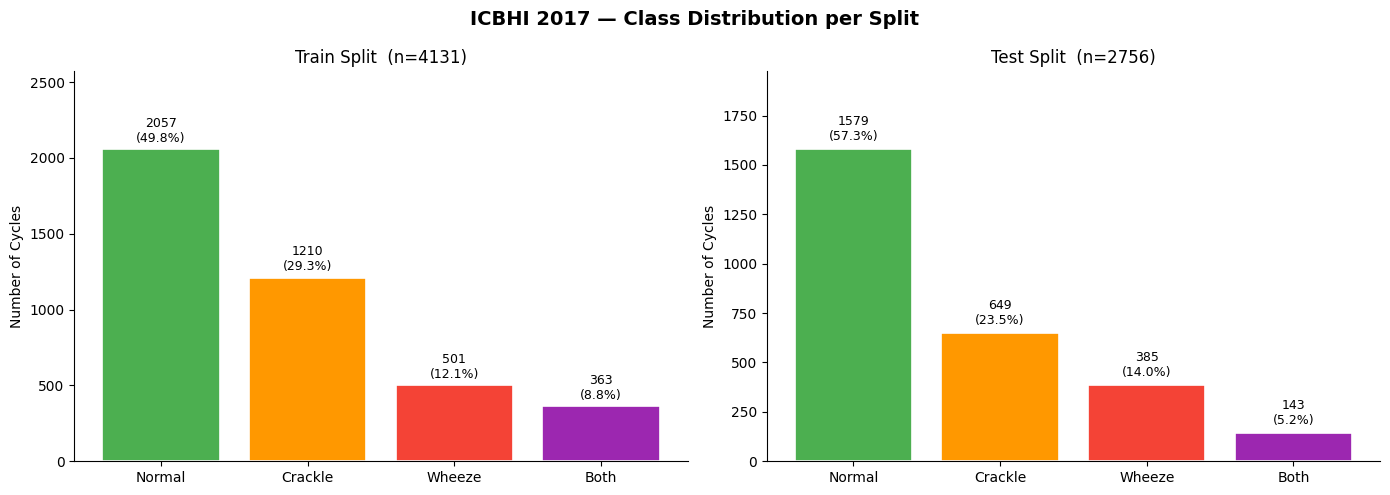


Key observation: Normal >> Crackle >> Wheeze >> Both
This imbalance is WHY WeightedRandomSampler + SpecAugment will be needed.
File          : 101_1b1_Al_sc_Meditron.wav
Sample rate   : 22050 Hz
Num samples   : 441,000
Duration      : 20.00 seconds
y dtype       : float32
y min/max     : -0.2001 / 0.4147
y shape       : (441000,)

Intuition:
  22050 samples/sec × 20.0 sec = 441,000 numbers
  Each number = air pressure at that instant (range: -1.0 to +1.0)

Playing audio in Colab...



Segmentation complete.
Saved   : 6857 cycles
Skipped : 41 cycles (already exist or too short)

Folder structure created:
  train/Normal   → 2031 cycles
  train/Crackle  → 1209 cycles
  train/Wheeze   → 499 cycles
  train/Both     → 363 cycles
  test/Normal   → 1571 cycles
  test/Crackle  → 647 cycles
  test/Wheeze   → 383 cycles
  test/Both     → 143 cycles
File          : 101_1b1_Al_sc_Meditron.wav
Sample rate   : 22050 Hz
Num samples   : 441,000
Duration      : 20.00 seconds
y dtype       : float32
y min/max     : -0.2001 / 0.4147
y shape       : (441000,)

Intuition:
  22050 samples/sec × 20.0 sec = 441,000 numbers
  Each number = air pressure at that instant (range: -1.0 to +1.0)

Playing audio in Colab...



Segmentation complete.
Saved   : 0 cycles
Skipped : 6898 cycles (already exist or too short)

Folder structure created:
  train/Normal   → 2031 cycles
  train/Crackle  → 1209 cycles
  train/Wheeze   → 499 cycles
  train/Both     → 363 cycles
  test/Normal   → 1571 cycles
  test/Crackle  → 647 cycles
  test/Wheeze   → 383 cycles
  test/Both     → 143 cycles


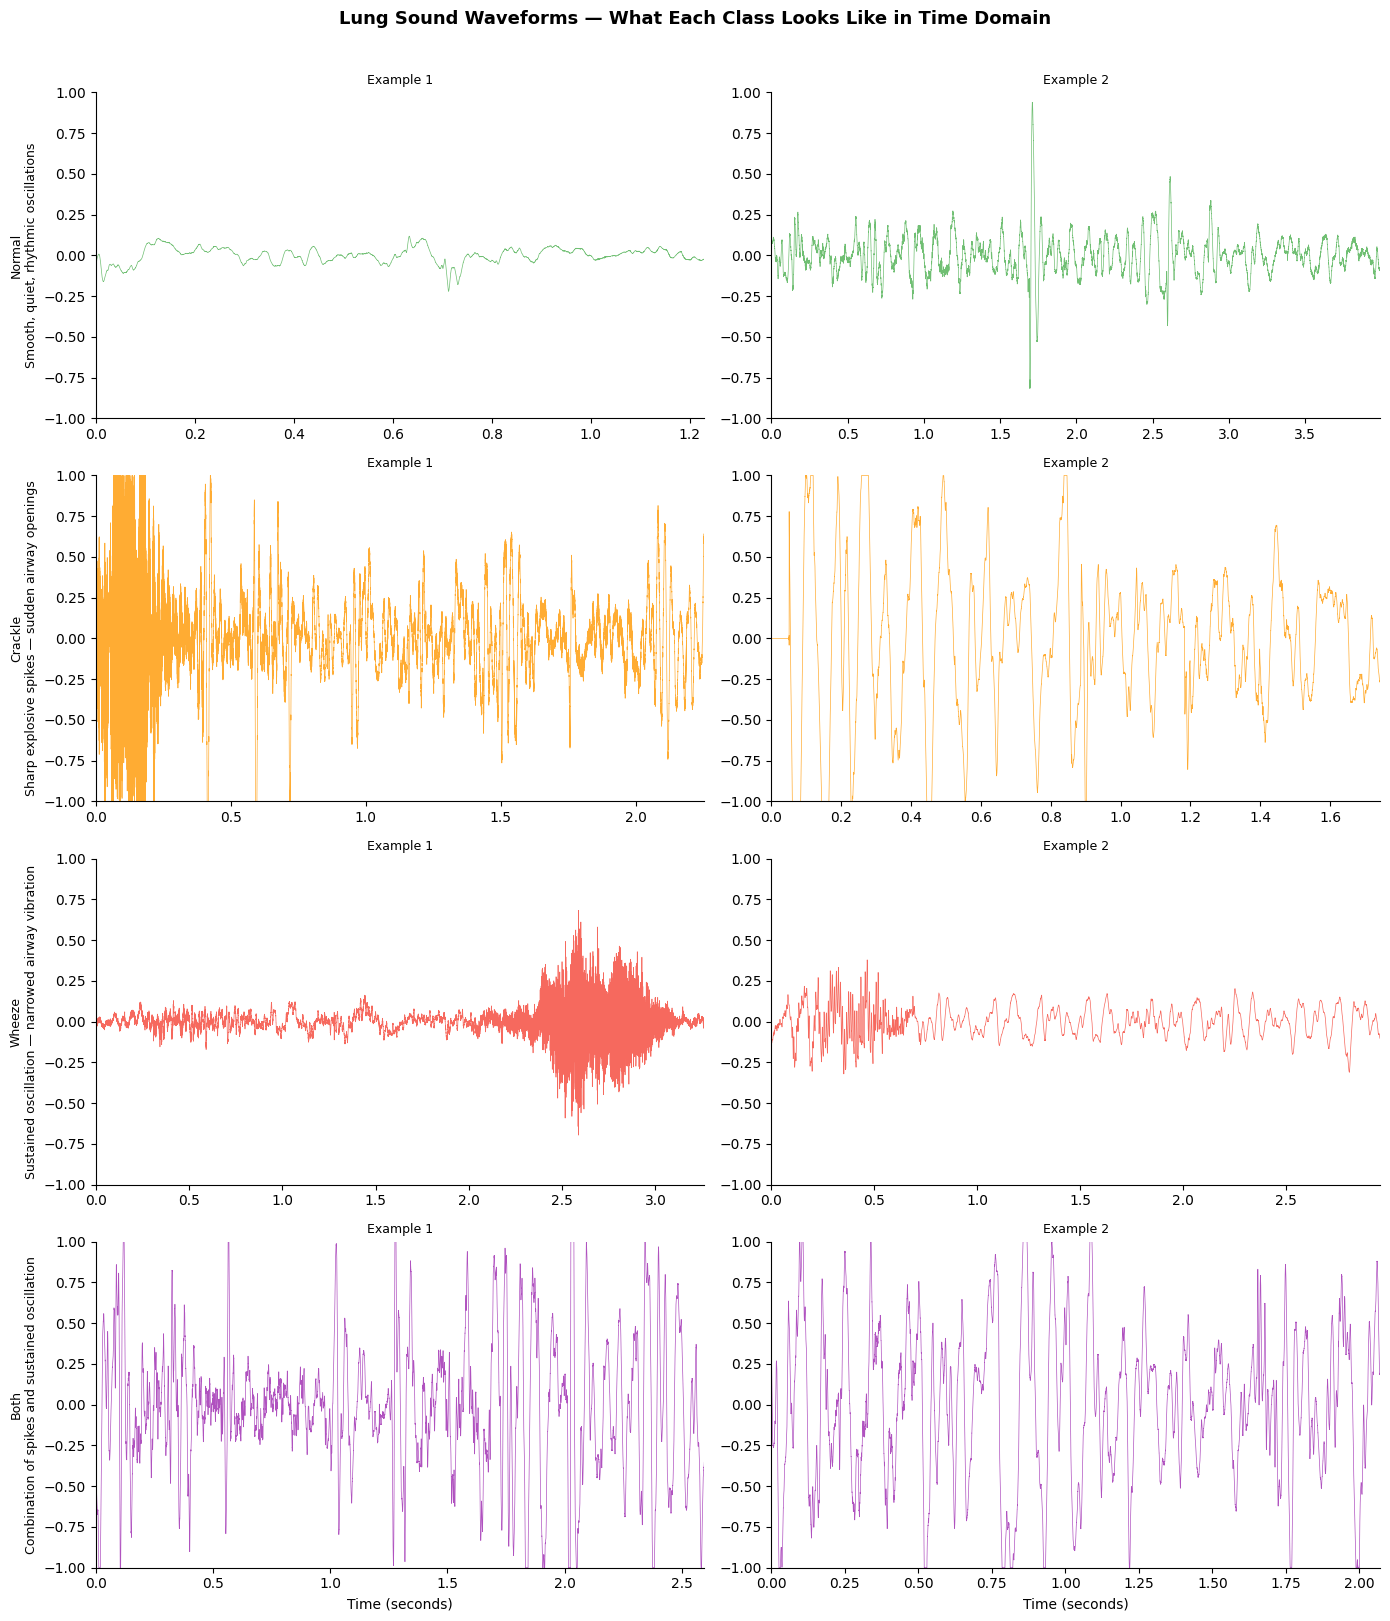


Study these waveforms carefully before moving to Phase 2.
The patterns you see here will become visible features in mel-spectrograms.

Class    : Normal
File     : 166_1p1_Ar_sc_Meditron_cycle3701.wav
Duration : 2.99s
Listen   ↓



Class    : Crackle
File     : 166_1p1_Ll_sc_Meditron_cycle3717.wav
Duration : 2.73s
Listen   ↓



Class    : Wheeze
File     : 172_1b4_Lr_mc_AKGC417L_cycle4055.wav
Duration : 2.87s
Listen   ↓



Class    : Both
File     : 130_3p3_Pr_mc_AKGC417L_cycle1477.wav
Duration : 2.98s
Listen   ↓



  PHASE 1 COMPLETE — DATA SUMMARY REPORT

Total breathing cycles  : 6,898
Unique patients         : 126
Unique recordings       : 920

── Class Distribution ────────────────────────────────
  Normal    3642  ( 52.8%)  ██████████████████████████
  Crackle   1864  ( 27.0%)  █████████████
  Wheeze     886  ( 12.8%)  ██████
  Both       506  (  7.3%)  ███

── Train / Test Split ────────────────────────────────
  train    4131  (59.9%)
  test     2756  (40.0%)

── Key Observations ──────────────────────────────────
  1. Normal cycles dominate (~53%) → class imbalance
  2. Wheeze + Both are minority classes (<10% combined)
  3. Split is by PATIENT (not cycle) → no data leakage
     (same patient never appears in both train and test)

  → These observations directly shape Phase 4 strategy:
    WeightedRandomSampler + SpecAugment on minority classes

── What Phase 2 Will Do ──────────────────────────────
  Convert every .wav cycle → mel-spectrogram → 224×224 PNG
  After Phase 2, this becomes 

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import import_ipynb
import Data_Audio_Fundementals as other

In [ ]:
"""
import os
from pathlib import Path
import import_ipynb

import Data_Audio_Fundementals as other



# Set the audio directory used by the notebook
other.audio_dir = os.path.join(
    CONFIG["raw_dir"],
    "audio_and_txt_files"
)



# Find an example WAV file
other.sample_wav = list(
    Path(other.audio_dir).glob("*.wav")
)[0]



# Demonstrate audio loading
other.y, sr = other.demonstrate_audio_loading(
    str(other.sample_wav),
    CONFIG["target_sr"]
)



# Segment and save breathing cycles
other.segment_and_save_cycles(
    master_df,
    CONFIG["cycles_dir"],
    CONFIG["target_sr"]
)



# Plot waveforms by class
other.plot_waveforms_by_class(
    CONFIG["cycles_dir"],
    CONFIG["target_sr"]
)



# Play examples from each class
other.play_class_examples(
    CONFIG["cycles_dir"],
    CONFIG["target_sr"]
)



# Generate Phase 1 summary report
other.phase1_summary_report(master_df)

"""


NameError: name 'CONFIG' is not defined